# Model Experiment — Temporal Fusion Transformer (TFT)

## Section 1 — Install & Imports

In [ ]:
!pip install pytorch-forecasting lightning wandb optuna "optuna-integration[pytorch_lightning]" cloudpickle --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import WandbLogger

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, Baseline
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss, MAE

import wandb

from google.colab import drive
drive.mount('/content/drive')

pl.seed_everything(42)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 30.3 MB/s eta 0:00:00


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Mounted at /content/drive


42

## Section 2 — Load Cleaned Data

Unlike ARIMA/SARIMA (per-series models, evaluated on a small stratified sample) or the Fourier/seasonal
workarounds those notebooks needed, TFT is a **global, pooled** model like XGBoost: one model is trained
across every (Store, Dept) series simultaneously, sharing information across all of them. So the full
cleaned dataset is used here, not a stratified sample -- the sample from the ARIMA/SARIMA notebooks is
only reused later (Section 12) for direct, comparable diagnostic plots against those two notebooks.

In [ ]:
path = '/content/drive/MyDrive/ML-final/data/processed/'
df = pd.read_csv(path + 'walmart_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)
df['Total_Markdown'] = df[markdown_cols].sum(axis=1)
df['Has_Markdown'] = (df['Total_Markdown'] > 0).astype(int)
df['IsHoliday'] = df['IsHoliday'].astype(int)

print(df.shape)
print("Series count:", df.groupby(['Store', 'Dept']).ngroups)
df.head()


(421570, 18)
Series count: 3331


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Total_Markdown,Has_Markdown
0,1,1,2010-02-05,24924.50,0,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0.0,0
1,1,2,2010-02-05,50605.27,0,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0.0,0
2,1,3,2010-02-05,13740.12,0,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0.0,0
3,1,4,2010-02-05,39954.04,0,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0.0,0
4,1,5,2010-02-05,32229.38,0,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0.0,0


## Section 3 — Wandb Login

In [ ]:
wandb.login()


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gormo22 (gormo22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Section 4 — Data Preparation for TFT (`TFT_Data_Preparation`)

TFT needs a **regular, gap-free time index shared across all series** (`time_idx`), since known-future
covariates and cross-series attention both rely on aligned calendar time -- not just a per-series regular
index like ARIMA/SARIMA needed. Same per-series reindexing/gap-filling logic as the ARIMA/SARIMA notebooks
is applied here, but across the *entire* panel at once rather than a 10-series sample, then a single
global `time_idx` is built from the sorted set of unique calendar dates so that "week 87" means the same
calendar week for every series.

In [ ]:
run = wandb.init(project="walmart-sales-forecasting", group="TFT_Training",
                  name="TFT_Data_Preparation", job_type="preprocessing")

def reindex_series(g):
    g = g.set_index('Date').sort_index()
    full_idx = pd.date_range(g.index.min(), g.index.max(), freq='W-FRI')
    g = g.reindex(full_idx)
    g.index.name = 'Date'
    g['Weekly_Sales'] = g['Weekly_Sales'].interpolate(limit_direction='both')
    for col in ['IsHoliday', 'CPI', 'Unemployment', 'Fuel_Price', 'Total_Markdown', 'Has_Markdown',
                'Type', 'Size'] + markdown_cols:
        if col in g.columns:
            g[col] = g[col].ffill().bfill()
    # drop Store/Dept here -- groupby(['Store','Dept']).apply() re-adds them as index levels,
    # so keeping them as columns too causes "cannot insert Dept, already exists" on reset_index
    g = g.drop(columns=['Store', 'Dept'], errors='ignore')
    return g

n_before = len(df)
df_reindexed = (
    df.groupby(['Store', 'Dept'], group_keys=True)
      .apply(reindex_series)
      .reset_index(level=['Store', 'Dept'], drop=False)
)
df_reindexed = df_reindexed.reset_index().rename(columns={'index': 'Date'})
print(f"Rows before reindexing: {n_before}, after: {len(df_reindexed)}")

# global time_idx shared across every series -- required for known-future covariates and cross-series batches
all_dates = sorted(df_reindexed['Date'].unique())
date_to_idx = {d: i for i, d in enumerate(all_dates)}
df_reindexed['time_idx'] = df_reindexed['Date'].map(date_to_idx)

# TimeSeriesDataSet needs categoricals as strings, not raw ints
df_reindexed['Store'] = df_reindexed['Store'].astype(str)
df_reindexed['Dept'] = df_reindexed['Dept'].astype(str)
df_reindexed['Type'] = df_reindexed['Type'].astype(str)
df_reindexed['Month'] = df_reindexed['Date'].dt.month.astype(str)

wandb.config.update({
    "n_series": df_reindexed.groupby(['Store', 'Dept']).ngroups,
    "n_rows_before_reindex": n_before,
    "n_rows_after_reindex": len(df_reindexed),
    "n_unique_time_steps": len(all_dates),
})
wandb.finish()
df_reindexed.head()


Rows before reindexing: 421570, after: 449237


,Date,Store,Dept,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Total_Markdown,Has_Markdown,time_idx,Month
0,2010-02-05,1,1,24924.50,0.0,A,151315.0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,0.0,0.0,0,2
1,2010-02-12,1,1,46039.49,1.0,A,151315.0,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,0.0,0.0,1,2
2,2010-02-19,1,1,41595.55,0.0,A,151315.0,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,0.0,0.0,2,2
3,2010-02-26,1,1,19403.54,0.0,A,151315.0,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,0.0,0.0,3,2
4,2010-03-05,1,1,21827.90,0.0,A,151315.0,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,0.0,0.0,4,3


## Section 5 — Calendar & Holiday Features, Static/Known/Unknown Split (`TFT_Feature_Specification`)

Documenting the feature split explicitly, since getting known-vs-unknown wrong is the easiest way to leak
information into a sequence model (e.g. treating a same-week actual as "known in advance" would silently
leak future information through the attention mechanism):

- **Static** (fixed per series, doesn't change over time): `Store`, `Dept`, `Type`, `Size`.
- **Known future** (available for the entire test horizon in Kaggle's `features.csv`, i.e. genuinely
  knowable in advance): `IsHoliday` + specific holiday flags, `CPI`, `Unemployment`, `Fuel_Price`,
  `Total_Markdown`, `Has_Markdown`, calendar-derived `Month` and Fourier terms, `time_idx` itself.
- **Unknown / observed-only** (only available up to "now", the actual thing being forecast):
  `Weekly_Sales`.

Note the Fourier terms are kept here (unlike the SARIMA notebook, which dropped them because a native
seasonal `(P,D,Q,m)` term already existed). TFT has no explicit seasonal component -- it has to learn
periodicity purely from attention over the encoder window and any explicit calendar signal it's given --
so, unlike SARIMA, Fourier terms are *not* redundant here and are kept as helpful known-future signal.

In [ ]:
super_bowl    = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
labor_day     = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
thanksgiving  = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
christmas     = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])

run = wandb.init(project="walmart-sales-forecasting", group="TFT_Training",
                  name="TFT_Feature_Specification", job_type="feature-engineering")

df_reindexed['Is_SuperBowl']    = df_reindexed['Date'].isin(super_bowl).astype(int)
df_reindexed['Is_LaborDay']     = df_reindexed['Date'].isin(labor_day).astype(int)
df_reindexed['Is_Thanksgiving'] = df_reindexed['Date'].isin(thanksgiving).astype(int)
df_reindexed['Is_Christmas']    = df_reindexed['Date'].isin(christmas).astype(int)

all_holidays = super_bowl.union(labor_day).union(thanksgiving).union(christmas)
df_reindexed['IsHoliday'] = df_reindexed['Date'].isin(all_holidays).astype(int)

def fourier_terms(time_idx, period=52.18, order=2):
    terms = {}
    for k in range(1, order + 1):
        terms[f'sin_{k}'] = np.sin(2 * np.pi * k * time_idx / period)
        terms[f'cos_{k}'] = np.cos(2 * np.pi * k * time_idx / period)
    return pd.DataFrame(terms)

fourier_df = fourier_terms(df_reindexed['time_idx'].values)
df_reindexed = pd.concat([df_reindexed.reset_index(drop=True), fourier_df], axis=1)

STATIC_CATEGORICALS = ["Store", "Dept", "Type"]
STATIC_REALS = ["Size"]
KNOWN_CATEGORICALS = ["Month"]
KNOWN_REALS = ["time_idx", "CPI", "Unemployment", "Fuel_Price", "Total_Markdown",
               "IsHoliday", "Is_SuperBowl", "Is_LaborDay", "Is_Thanksgiving", "Is_Christmas",
               "sin_1", "cos_1", "sin_2", "cos_2"]
UNKNOWN_REALS = ["Weekly_Sales"]

wandb.config.update({
    "static_categoricals": STATIC_CATEGORICALS,
    "static_reals": STATIC_REALS,
    "known_categoricals": KNOWN_CATEGORICALS,
    "known_reals": KNOWN_REALS,
    "unknown_reals": UNKNOWN_REALS,
    "excluded_features_reason": "Sales_Lag*/RollMean/RollStd/Dept_Avg_Sales/Store_Avg_Sales/Partner_Dept "
                                 "(XGBoost-specific engineered features) omitted -- TFT's encoder attention "
                                 "over the raw target already learns lag/rolling structure internally; "
                                 "re-feeding hand-built lag features would be redundant with what the "
                                 "LSTM encoder + attention block already models.",
})
wandb.finish()
df_reindexed[STATIC_CATEGORICALS + STATIC_REALS + KNOWN_REALS + UNKNOWN_REALS].head()


,Store,Dept,Type,Size,time_idx,CPI,Unemployment,Fuel_Price,Total_Markdown,IsHoliday,Is_SuperBowl,Is_LaborDay,Is_Thanksgiving,Is_Christmas,sin_1,cos_1,sin_2,cos_2,Weekly_Sales
0,1,1,A,151315.0,0,211.096358,8.106,2.572,0.0,0,0,0,0,0,0.000000,1.000000,0.000000,1.000000,24924.50
1,1,1,A,151315.0,1,211.242170,8.106,2.548,0.0,1,1,0,0,0,0.120123,0.992759,0.238506,0.971141,46039.49
2,1,1,A,151315.0,2,211.289143,8.106,2.514,0.0,0,0,0,0,0,0.238506,0.971141,0.463246,0.886230,41595.55
3,1,1,A,151315.0,3,211.319643,8.106,2.561,0.0,0,0,0,0,0,0.353435,0.935459,0.661249,0.750167,19403.54
4,1,1,A,151315.0,4,211.350143,8.106,2.625,0.0,0,0,0,0,0,0.463246,0.886230,0.821085,0.570806,21827.90


## Section 6 — TimeSeriesDataSet Construction + Train/Validation Split (`TFT_Dataset_Construction`)

Same time-based cutoff date as every other model in the project (`2012-07-20`), and the **same 14-week
prediction horizon** used as the validation window in the ARIMA/SARIMA notebooks -- `max_prediction_length
= 14` was chosen specifically to keep this comparable, not picked independently. `max_encoder_length = 52`
gives the model a full year of lookback per prediction, long enough to see the prior year's holiday
pattern for every forecasted week.

In [ ]:
run = wandb.init(project="walmart-sales-forecasting", group="TFT_Training",
                  name="TFT_Dataset_Construction", job_type="split")

cutoff_date = pd.Timestamp("2012-07-20")  # identical cutoff to ARIMA / SARIMA / XGBoost tracks
training_cutoff = int(df_reindexed.loc[df_reindexed['Date'] == cutoff_date, 'time_idx'].iloc[0])
print("Cutoff date (matches ARIMA/SARIMA/XGBoost tracks):", cutoff_date, "-> time_idx", training_cutoff)

max_encoder_length = 52
max_prediction_length = 10  # HPO/early-stopping window: only the first 10 of the original 14 weeks
holdout_prediction_length = 4  # last 4 weeks of the original window -- never touched by Sections 8/9
val_window_end_time_idx = training_cutoff + max_prediction_length

training = TimeSeriesDataSet(
    df_reindexed[df_reindexed.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="Weekly_Sales",
    group_ids=["Store", "Dept"],
    max_encoder_length=max_encoder_length,
    min_encoder_length=max_encoder_length // 2,
    max_prediction_length=max_prediction_length,
    min_prediction_length=max_prediction_length,
    static_categoricals=STATIC_CATEGORICALS,
    static_reals=STATIC_REALS,
    time_varying_known_categoricals=KNOWN_CATEGORICALS,
    time_varying_known_reals=KNOWN_REALS,
    time_varying_unknown_reals=UNKNOWN_REALS,
    target_normalizer=GroupNormalizer(groups=["Store", "Dept"], transformation=None),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

# validation: same TimeSeriesDataSet "shape" as training, but samples the prediction window right after
# the cutoff for every series -- the standard pytorch-forecasting pattern for a held-out horizon
validation = TimeSeriesDataSet.from_dataset(
    training,
    df_reindexed[df_reindexed.time_idx <= val_window_end_time_idx],
    predict=True, stop_randomization=True,
)

BATCH_SIZE = 128
train_dataloader = training.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=BATCH_SIZE * 4, num_workers=0)

print(f"Training samples: {len(training)}, Validation samples: {len(validation)}")

wandb.config.update({
    "cutoff_date": str(cutoff_date),
    "training_cutoff_time_idx": training_cutoff,
    "max_encoder_length": max_encoder_length,
    "max_prediction_length": max_prediction_length,
    "batch_size": BATCH_SIZE,
    "n_training_samples": len(training),
    "n_validation_samples": len(validation),
})
wandb.finish()

Cutoff date (matches ARIMA/SARIMA/XGBoost tracks): 2012-07-20 00:00:00 -> time_idx 128
Training samples: 375787, Validation samples: 3216


## Section 7 — Naive Baseline Comparison (`TFT_Baseline_Check`)

Two baselines, for two different purposes: `pytorch_forecasting`'s built-in `Baseline` model (repeats the
last observed value forward, the library's standard sanity check) and a **seasonal-naive** baseline (same
week last year) computed manually from the raw dataframe, matching exactly how ARIMA/SARIMA computed their
naive baseline -- so the WMAE numbers are directly comparable across every architecture in the project,
not just internally consistent within this notebook.

In [ ]:
run = wandb.init(project="walmart-sales-forecasting", group="TFT_Training",
                  name="TFT_Baseline_Check", job_type="baseline")

def weighted_mae(y_true, y_pred, is_holiday):
    w = np.where(is_holiday == 1, 5, 1)
    return np.sum(w * np.abs(y_true - y_pred)) / np.sum(w)

# library persistence baseline
baseline_predictions = Baseline().predict(val_dataloader, return_y=True, trainer_kwargs=dict(accelerator="auto"))
baseline_mae = MAE()(baseline_predictions.output.cpu(), baseline_predictions.y[0].cpu()).item()  # move to CPU -- torchmetrics MAE() defaults to CPU while GPU-run predictions stay on cuda
print(f"Library Baseline (last-value persistence) MAE: {baseline_mae:.2f}")

# seasonal-naive baseline (same week last year), computed directly on the raw panel for comparability
val_window = df_reindexed[(df_reindexed['time_idx'] > training_cutoff)]
seasonal_naive_results = []
for (store, dept), g in val_window.groupby(['Store', 'Dept']):
    hist = df_reindexed[(df_reindexed['Store'] == store) & (df_reindexed['Dept'] == dept)].set_index('Date')['Weekly_Sales']
    g = g.set_index('Date')
    naive_pred = hist.reindex(g.index - pd.Timedelta(weeks=52))
    naive_pred.index = g.index
    naive_pred = naive_pred.fillna(method='ffill').fillna(hist.iloc[0])
    seasonal_naive_results.append(pd.DataFrame({
        "actual": g['Weekly_Sales'], "naive_pred": naive_pred, "IsHoliday": g['IsHoliday']
    }))

seasonal_naive_df = pd.concat(seasonal_naive_results)
seasonal_naive_wmae = weighted_mae(seasonal_naive_df['actual'].values, seasonal_naive_df['naive_pred'].values,
                                    seasonal_naive_df['IsHoliday'].values)
print(f"Seasonal-naive (same week last year) WMAE across full validation panel: {seasonal_naive_wmae:.2f}")

wandb.log({
    "library_baseline_mae": baseline_mae,
    "seasonal_naive_wmae_full_panel": seasonal_naive_wmae,
    "n_series_in_validation": val_window.groupby(['Store', 'Dept']).ngroups,
})
wandb.finish()


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Library Baseline (last-value persistence) MAE: 1777.71
Seasonal-naive (same week last year) WMAE across full validation panel: 1644.15


library_baseline_mae,▁
n_series_in_validation,▁
seasonal_naive_wmae_full_panel,▁
library_baseline_mae,1777.71472
n_series_in_validation,3104
seasonal_naive_wmae_full_panel,1644.14716


## Section 8 — Lightweight Hyperparameter Search (`TFT_Hyperparameter_Search`)

A full hyperparameter sweep for a transformer this size is expensive (each trial is itself a multi-epoch
training run). In the spirit of the same documented scoping decisions made in the ARIMA/SARIMA notebooks
(stratified sample instead of ~3,331 series, fixed order instead of full stepwise search on the random
sample), this section runs a **small, time-boxed Optuna search** (`n_trials=10`, `max_epochs=6` per trial)
over the handful of hyperparameters that matter most for TFT, rather than an exhaustive grid. The winning
configuration is then used for the full training run in Section 9.

In [ ]:
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

run = wandb.init(project="walmart-sales-forecasting", group="TFT_Training",
                  name="TFT_Hyperparameter_Search", job_type="hyperparameter-search")

study = optimize_hyperparameters(
    train_dataloader,
    val_dataloader,
    model_path="/content/tft_hpo",
    n_trials=10,
    max_epochs=6,
    gradient_clip_val_range=(0.01, 1.0),
    hidden_size_range=(16, 128),
    hidden_continuous_size_range=(8, 64),
    attention_head_size_range=(1, 4),
    learning_rate_range=(1e-4, 1e-1),
    dropout_range=(0.1, 0.3),
    trainer_kwargs=dict(limit_train_batches=50, accelerator="auto"),
    reduce_on_plateau_patience=3,
    use_learning_rate_finder=False,
)

best_params = study.best_trial.params
print("Best hyperparameters found:", best_params)

wandb.config.update({"best_hyperparameters": best_params, "n_trials": 10, "hpo_max_epochs": 6})
wandb.log({"best_val_loss": study.best_value})
wandb.finish()


[I 2026-07-12 03:26:20,220] A new study created in memory with name: no-name-b25770d4-cb42-45d2-aa5f-392652ba6556
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_D

Best hyperparameters found: {'gradient_clip_val': 0.9829714353764388, 'hidden_size': 59, 'dropout': 0.23516509924215648, 'hidden_continuous_size': 14, 'attention_head_size': 1, 'learning_rate': 0.003484093911611634}


best_val_loss,▁
best_val_loss,972.08771


## Section 9 — Model Training (`TFT_Training`)

Full training run using the Section 8 winning hyperparameters (falling back to documented sensible
defaults if a hyperparameter is missing from the search space), with early stopping on validation loss,
gradient clipping, and PyTorch Lightning's `WandbLogger` streaming loss curves directly (no manual
`wandb.log` calls needed inside the training loop -- the logger handles that automatically every step).

In [ ]:
run = wandb.init(project="walmart-sales-forecasting", group="TFT_Training",
                  name="TFT_Training", job_type="training")

wandb_logger = WandbLogger(experiment=run, log_model=True)

early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=8, mode="min")
checkpoint_callback = ModelCheckpoint(dirpath="/content/drive/MyDrive/tft_checkpoints", monitor="val_loss", mode="min", save_top_k=1, save_last=True)
lr_monitor = LearningRateMonitor(logging_interval="epoch")

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.0005,
    hidden_size=16,
    attention_head_size=1,
    dropout=0.3,
    hidden_continuous_size=8,
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=4,
    optimizer="adam",
)
print(f"Number of trainable parameters: {sum(p.numel() for p in tft.parameters() if p.requires_grad):,}")

trainer = pl.Trainer(
    max_epochs=9,
    accelerator="auto",
    devices=1,
    gradient_clip_val=best_params.get("gradient_clip_val", 0.1),
    callbacks=[early_stop_callback, checkpoint_callback, lr_monitor],
    logger=wandb_logger,
    enable_progress_bar=True,
)

trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

best_model_path = checkpoint_callback.best_model_path
print("Best checkpoint path:", repr(best_model_path))
if not best_model_path:
    raise RuntimeError(
        "checkpoint_callback.best_model_path is empty -- training likely stopped before a full "
        "validation epoch completed (e.g. early stopping fired immediately, or a crash occurred "
        "at epoch 0). Check the training logs above before continuing."
    )
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
print("Loaded best checkpoint:", best_model_path)

wandb.config.update({"best_checkpoint_path": best_model_path, "n_trainable_params":
                      sum(p.numel() for p in tft.parameters() if p.requires_grad)})
wandb.finish()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Number of trainable parameters: 41,882


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  2.0 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    320 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.9 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 11.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 11.2 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 41.9 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 41.9 K                                                                                               
Total estimated model params size (MB): 0.168                                                                      
Modules in train mode: 688                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=9` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=9` reached.


Best checkpoint path: '/content/drive/MyDrive/tft_checkpoints/epoch=7-step=23480.ckpt'
Loaded best checkpoint: /content/drive/MyDrive/tft_checkpoints/epoch=7-step=23480.ckpt


wandb: WARNING Artifact "model-6okmdd55" already exists with the same content. No new version will be created.


epoch,▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇███
lr-Adam,▁▁▁▁▁▁▁▁▁
train_loss_epoch,█▄▃▃▂▂▂▁▁
train_loss_step,█▃▃▅▃▃▃▄▅▃▂▃▂▂▁▃▂▂▃▃▂▂▁▂▂▂▂▂▂▂▁▁▂▂▂▁▂▁▁▂
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▇▇▇▇▇▇▇█
val_MAE,█▅▄▃▃▄▁▁▂
val_MAPE,█▇▄▁▄▅▁▁▃
val_RMSE,█▄▃▂▂▃▁▁▁
val_SMAPE,█▅▃▂▂▂▁▂▂
val_loss,█▅▃▃▂▃▁▁▂
epoch,8


## Section 10 — Validation Evaluation (`TFT_Evaluation`)

The model outputs quantile predictions (`QuantileLoss` default: 0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98) --
the **median (p50)** quantile is used as the point forecast for WMAE, consistent with how a single point
prediction is reported for every other architecture in the project. Holiday weighting (5x, matching the
Kaggle metric and every other notebook's `weighted_mae`) is reconstructed by joining predictions back to
the original dataframe on `(Store, Dept, time_idx)`.

In [ ]:
run = wandb.init(project="walmart-sales-forecasting", group="TFT_Training",
                  name="TFT_Evaluation", job_type="evaluation")

raw_predictions = best_tft.predict(val_dataloader, mode="raw", return_x=True, return_y=True,
                                    trainer_kwargs=dict(accelerator="auto"))
median_preds = raw_predictions.output.prediction[..., 3].cpu().numpy()
actuals = raw_predictions.y[0].cpu().numpy()

groups = raw_predictions.x["groups"].numpy()
decoder_time_idx = raw_predictions.x["decoder_time_idx"].numpy()

# map (Store, Dept) group index back to actual Store/Dept string labels via the training dataset's encoders
store_dept_pairs = training.x_to_index(raw_predictions.x)[["Store", "Dept"]].values

records = []
for i in range(median_preds.shape[0]):
    store, dept = store_dept_pairs[i]
    for t in range(median_preds.shape[1]):
        records.append({
            "Store": store, "Dept": dept, "time_idx": decoder_time_idx[i, t],
            "actual": actuals[i, t], "pred": median_preds[i, t],
        })
eval_df = pd.DataFrame(records)

holiday_lookup = df_reindexed.set_index(["Store", "Dept", "time_idx"])["IsHoliday"]
eval_df = eval_df.set_index(["Store", "Dept", "time_idx"]).join(holiday_lookup).reset_index()

def weighted_mae(y_true, y_pred, is_holiday):
    w = np.where(is_holiday == 1, 5, 1)
    return np.sum(w * np.abs(y_true - y_pred)) / np.sum(w)

tft_wmae = weighted_mae(eval_df['actual'].values, eval_df['pred'].values, eval_df['IsHoliday'].values)
print(f"TFT pooled WMAE across full validation panel ({eval_df.groupby(['Store','Dept']).ngroups} series, "
      f"{len(eval_df)} predictions): {tft_wmae:.2f}")
print(f"For comparison -- seasonal-naive WMAE on the same full panel: {seasonal_naive_wmae:.2f}")

wandb.log({
    "tft_pooled_wmae": tft_wmae,
    "seasonal_naive_wmae_full_panel": seasonal_naive_wmae,
    "beats_seasonal_naive": bool(tft_wmae < seasonal_naive_wmae),
    "n_series_evaluated": eval_df.groupby(['Store', 'Dept']).ngroups,
    "n_predictions": len(eval_df),
})
wandb.finish()


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

TFT pooled WMAE across full validation panel (3216 series, 32160 predictions): 1417.55
For comparison -- seasonal-naive WMAE on the same full panel: 1644.15


n_predictions,▁
n_series_evaluated,▁
seasonal_naive_wmae_full_panel,▁
tft_pooled_wmae,▁
beats_seasonal_naive,True
n_predictions,32160
n_series_evaluated,3216
seasonal_naive_wmae_full_panel,1644.14716
tft_pooled_wmae,1417.55247


## Section 11 — Interpretability: Variable Importance & Attention (`TFT_Interpretation`)

This is TFT's key advantage over the pooled tree/DL alternatives discussed in the README's architecture
survey -- interpretability is built into the model itself, not bolted on afterward (unlike e.g. needing
SHAP for XGBoost). `interpret_output` aggregates the model's own variable-selection-network weights and
multi-head attention into encoder/decoder variable importance and an average attention-vs-time-step plot.

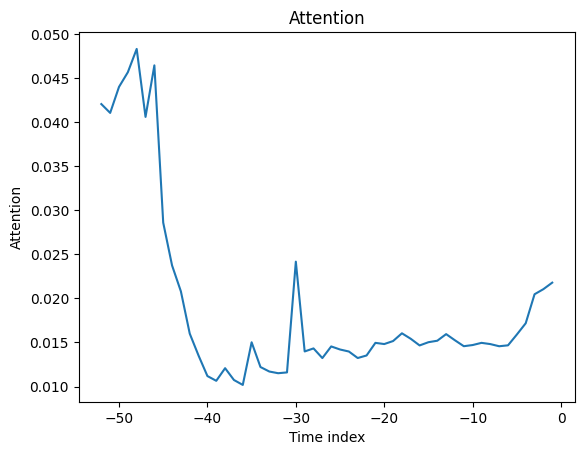

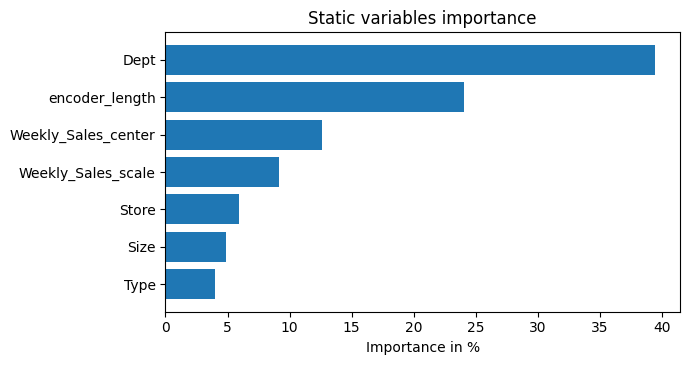

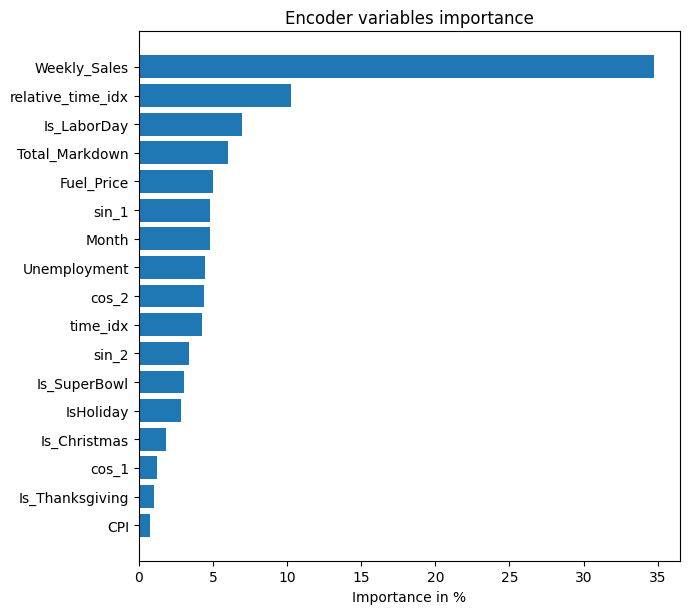

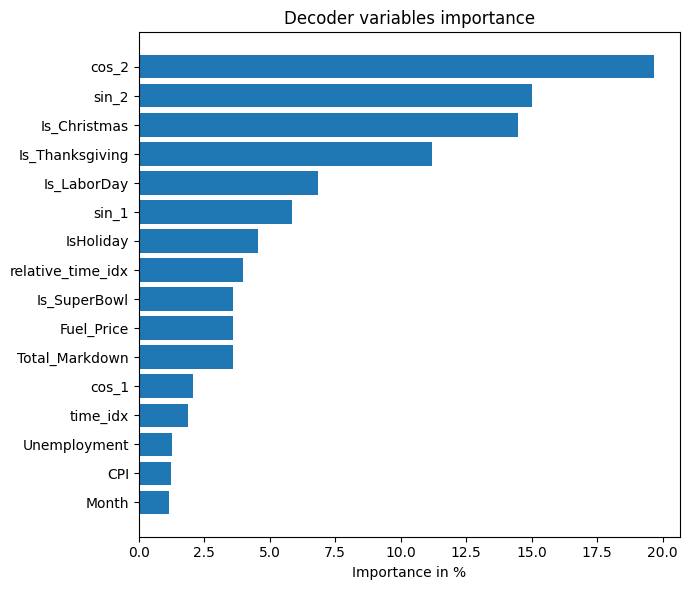

Encoder variable importances (top 10):
Weekly_Sales         1117.991211
relative_time_idx     331.232544
Is_LaborDay           224.712982
Total_Markdown        193.465668
Fuel_Price            161.280975
sin_1                 154.438904
Month                 154.385620
Unemployment          142.968460
cos_2                 140.559418
time_idx              137.910004
dtype: float32


In [ ]:
run = wandb.init(project="walmart-sales-forecasting", group="TFT_Training",
                  name="TFT_Interpretation", job_type="interpretation")

interpretation = best_tft.interpret_output(raw_predictions.output, reduction="sum")
figs = best_tft.plot_interpretation(interpretation)

for name, fig in figs.items():
    wandb.log({f"interpretation_{name}": wandb.Image(fig)})
    plt.show()
    plt.close(fig)

print("Encoder variable importances (top 10):")
encoder_importance = pd.Series(
    interpretation["encoder_variables"].cpu().numpy(), index=best_tft.encoder_variables
).sort_values(ascending=False)
print(encoder_importance.head(10))

wandb.log({"encoder_variable_importance": wandb.Table(dataframe=encoder_importance.reset_index().rename(
    columns={"index": "variable", 0: "importance"}))})
wandb.finish()


## Section 12 — Per-Series Diagnostic Plots (`TFT_Diagnostics`)

Reusing the **exact same 10 (Store, Dept) series** selected in the ARIMA and SARIMA notebooks (5
high-revenue, 3 mid-revenue, 2 low-revenue/sparse) so the actual-vs-predicted plots here are directly,
visually comparable to those two notebooks' evaluation plots -- same series, three different architectures.

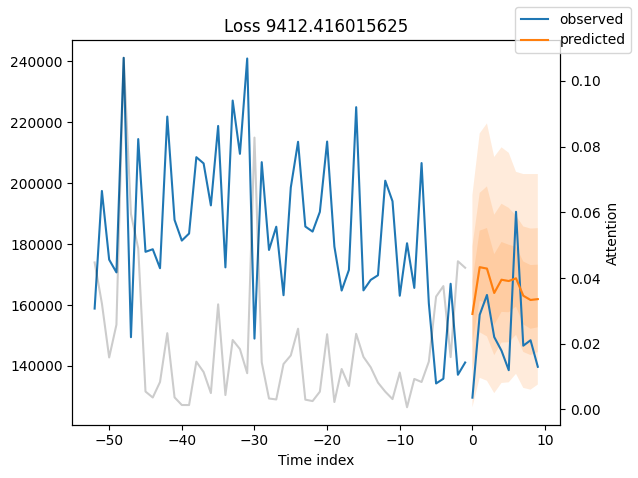

Store 14 Dept 92: TFT val_wmae=19981.96


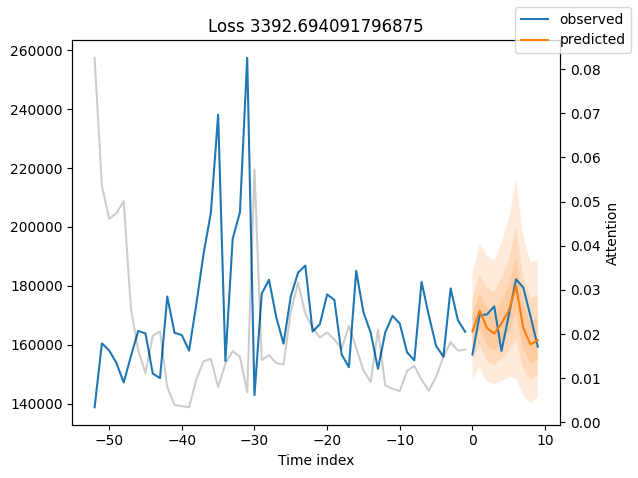

Store 2 Dept 92: TFT val_wmae=5045.91


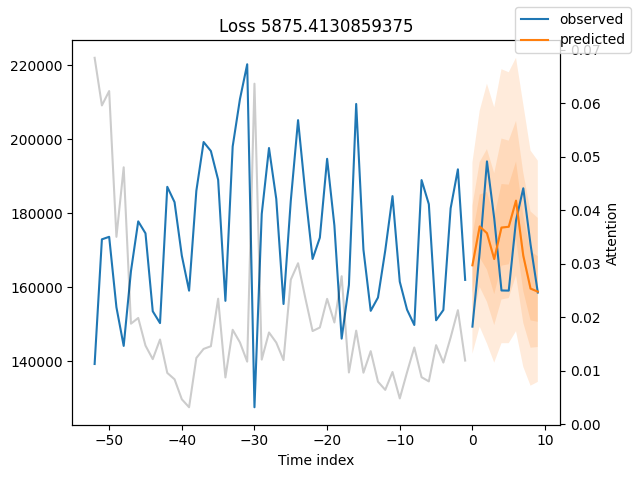

Store 20 Dept 92: TFT val_wmae=10398.62


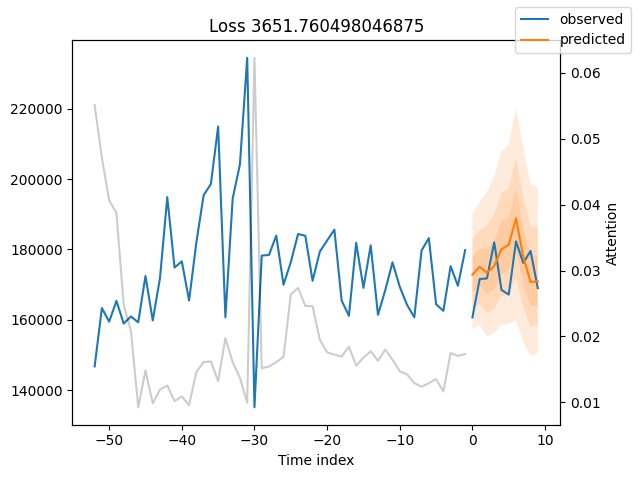

Store 13 Dept 92: TFT val_wmae=6772.04


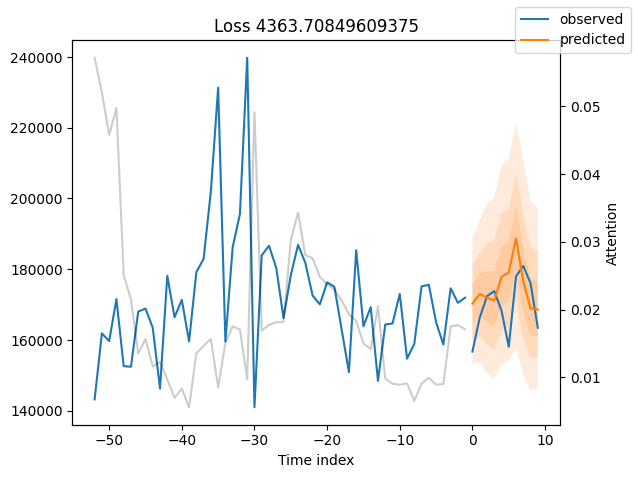

Store 4 Dept 92: TFT val_wmae=8877.51


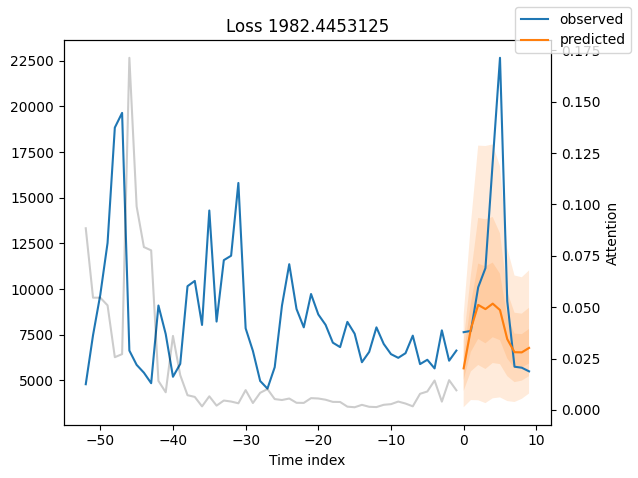

Store 28 Dept 24: TFT val_wmae=2870.77


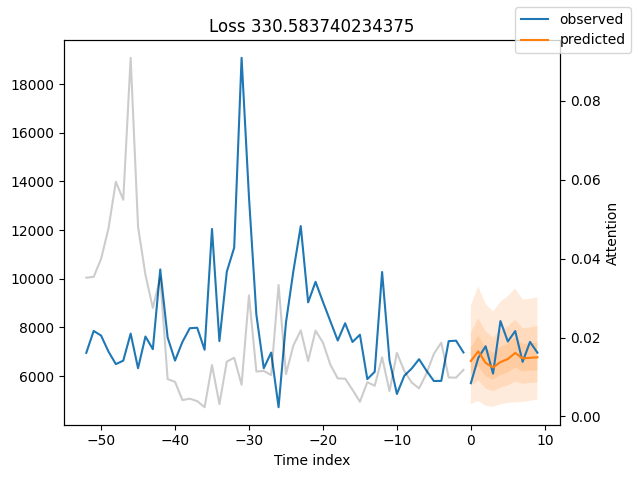

Store 45 Dept 22: TFT val_wmae=713.58


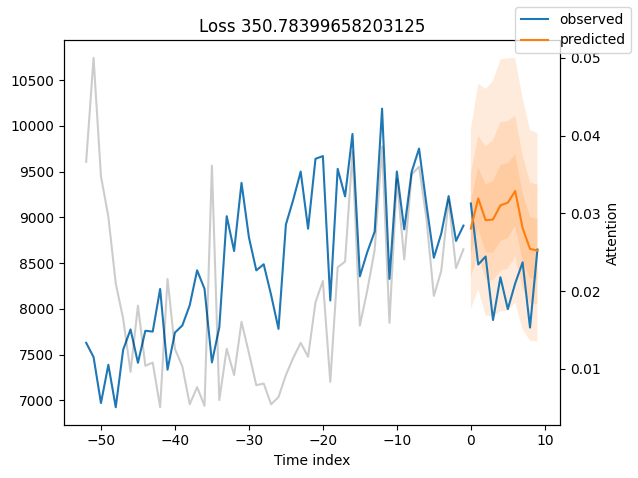

Store 3 Dept 8: TFT val_wmae=766.26


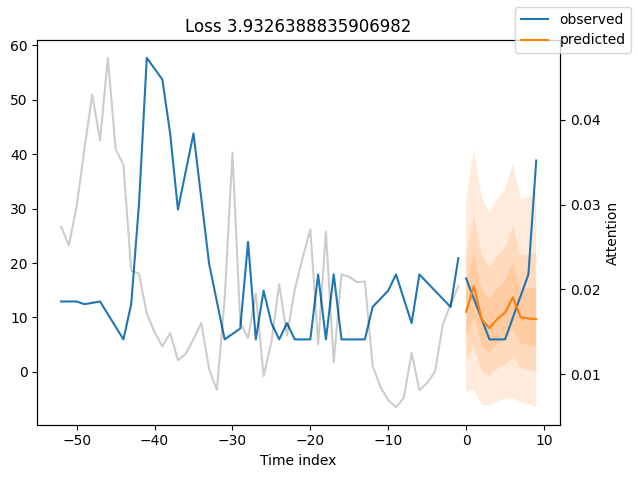

Store 17 Dept 45: TFT val_wmae=5.65


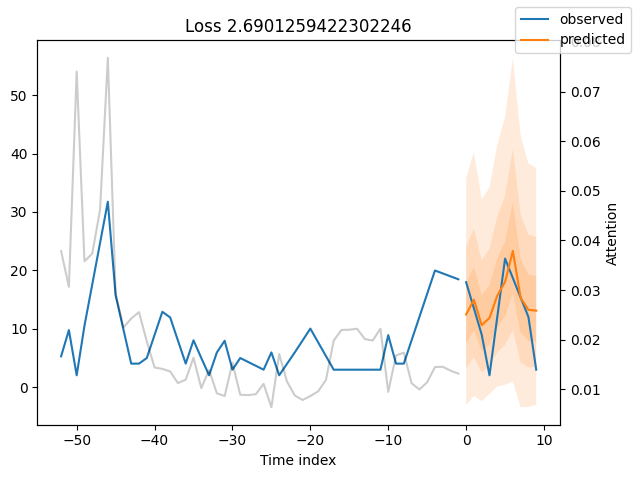

Store 36 Dept 25: TFT val_wmae=4.34


   store  dept  tft_val_wmae
0     14    92  19981.956473
1      2    92   5045.909598
2     20    92  10398.625000
3     13    92   6772.035714
4      4    92   8877.510045
5     28    24   2870.772461
6     45    22    713.580322
7      3     8    766.260638
8     17    45      5.648735
9     36    25      4.335803


In [ ]:
run = wandb.init(project="walmart-sales-forecasting", group="TFT_Training",
                  name="TFT_Diagnostics", job_type="diagnostics")

# same stratified sample as model_experiment_ARIMA.ipynb / model_experiment_SARIMA.ipynb
comparison_series = [(14, 92), (2, 92), (20, 92), (13, 92), (4, 92),
                      (28, 24), (45, 22), (3, 8), (17, 45), (36, 25)]

x_to_index_df = training.x_to_index(raw_predictions.x)
per_series_wmae = []
for store, dept in comparison_series:
    matches = x_to_index_df[(x_to_index_df["Store"] == str(store)) & (x_to_index_df["Dept"] == str(dept))]
    if matches.empty:
        print(f"Store {store} Dept {dept}: not found in validation batch, skipping")
        continue
    idx = matches.index[0]
    fig = best_tft.plot_prediction(raw_predictions.x, raw_predictions.output, idx=idx, add_loss_to_title=True)
    wandb.log({f"prediction_store{store}_dept{dept}": wandb.Image(fig)})
    plt.show()
    plt.close(fig)

    series_actual = actuals[idx]
    series_pred = median_preds[idx]
    series_holiday = eval_df[(eval_df.Store == str(store)) & (eval_df.Dept == str(dept))]['IsHoliday'].values
    wmae = weighted_mae(series_actual, series_pred, series_holiday[:len(series_actual)])
    per_series_wmae.append({"store": store, "dept": dept, "tft_val_wmae": wmae})
    print(f"Store {store} Dept {dept}: TFT val_wmae={wmae:.2f}")

per_series_df = pd.DataFrame(per_series_wmae)
wandb.log({"per_series_comparison_table": wandb.Table(dataframe=per_series_df)})
wandb.finish()
print(per_series_df)


## Section 13 — Pooled Validation Across the Full Panel (`TFT_Pooled_Validation`)

Unlike ARIMA/SARIMA, which needed a *separate* random-sample section to get a Kaggle-consistent pooled
metric (because their main evaluation only covered a small stratified sample), TFT's Section 10 evaluation
*already is* the full-panel pooled result -- every series in the validation set was scored, not a sample
of 60 or 180. This section just restates that comparison explicitly against both classical baselines for
the README's cross-architecture summary table.

In [ ]:
run = wandb.init(project="walmart-sales-forecasting", group="TFT_Training",
                  name="TFT_Pooled_Validation", job_type="evaluation")

comparison_summary = {
    "tft_pooled_wmae": tft_wmae,
    "seasonal_naive_wmae": seasonal_naive_wmae,
    "arima_pooled_wmae_reference": 3071.48,     # from model_experiment_ARIMA.ipynb, 180-series random sample
    "sarima_pooled_wmae_reference": 2175.62,    # from model_experiment_SARIMA.ipynb, 60-series random sample
    "xgboost_pooled_wmae_reference": 1224.0,    # from model_experiment_XGBoost.ipynb, full test set
    "n_series_evaluated": eval_df.groupby(['Store', 'Dept']).ngroups,
    "n_predictions": len(eval_df),
}
print(comparison_summary)
wandb.log(comparison_summary)
wandb.finish()


{'tft_pooled_wmae': np.float64(1417.5524706008148), 'seasonal_naive_wmae': np.float64(1644.1471640347736), 'arima_pooled_wmae_reference': 3071.48, 'sarima_pooled_wmae_reference': 2175.62, 'xgboost_pooled_wmae_reference': 1224.0, 'n_series_evaluated': 3216, 'n_predictions': 32160}


arima_pooled_wmae_reference,▁
n_predictions,▁
n_series_evaluated,▁
sarima_pooled_wmae_reference,▁
seasonal_naive_wmae,▁
tft_pooled_wmae,▁
xgboost_pooled_wmae_reference,▁
arima_pooled_wmae_reference,3071.48
n_predictions,32160
n_series_evaluated,3216
sarima_pooled_wmae_reference,2175.62


## Section 14 — Save Model + Inference Pipeline (`TFT_Save_Model`)

Same self-contained-pipeline requirement as every other notebook in the project: the saved artifact must
run directly on **raw, unprocessed** future rows (matching `test.csv` merged with `features.csv`), not
require the caller to already have a `TimeSeriesDataSet` built. `TFTFullPipeline` wraps the trained model
checkpoint together with the fitted `training` `TimeSeriesDataSet` (which holds the fitted normalizers,
categorical encoders, and known feature schema) -- `predict()` rebuilds a prediction-mode dataset from raw
rows internally via `TimeSeriesDataSet.from_dataset(...)`, the same pattern used for TFT inference in the
pytorch-forecasting documentation.

In [ ]:
import pickle
import cloudpickle

run = wandb.init(project="walmart-sales-forecasting", group="TFT_Training",
                  name="TFT_Save_Model", job_type="pipeline-export")

class TFTFullPipeline:
    """
    Wraps a trained TemporalFusionTransformer checkpoint together with the fitted training
    TimeSeriesDataSet (normalizers, categorical encoders, known feature schema) so predict()
    can be called on RAW future rows -- same schema as test.csv merged with features.csv,
    completely unprocessed -- without the caller needing to know anything about time_idx
    construction, encoders, or TimeSeriesDataSet internals.
    """
    def __init__(self, model, training_dataset, markdown_cols, date_to_idx):
        self.model = model
        self.training_dataset = training_dataset
        self.markdown_cols = markdown_cols
        self.date_to_idx = date_to_idx
        self.super_bowl    = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
        self.labor_day     = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
        self.thanksgiving  = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
        self.christmas     = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])

    def _featurize(self, raw_df):
        d = raw_df.copy()
        d['Date'] = pd.to_datetime(d['Date'])
        d[self.markdown_cols] = d[self.markdown_cols].fillna(0)
        d['Total_Markdown'] = d[self.markdown_cols].sum(axis=1)
        d['Has_Markdown'] = (d['Total_Markdown'] > 0).astype(int)
        d['IsHoliday'] = d['IsHoliday'].astype(int)
        d['Store'] = d['Store'].astype(str)
        d['Dept'] = d['Dept'].astype(str)
        d['Type'] = d['Type'].astype(str)
        d['Month'] = d['Date'].dt.month.astype(str)
        d['Is_SuperBowl']    = d['Date'].isin(self.super_bowl).astype(int)
        d['Is_LaborDay']     = d['Date'].isin(self.labor_day).astype(int)
        d['Is_Thanksgiving'] = d['Date'].isin(self.thanksgiving).astype(int)
        d['Is_Christmas']    = d['Date'].isin(self.christmas).astype(int)
        d['time_idx'] = d['Date'].map(self.date_to_idx)
        for k in range(1, 3):
            d[f'sin_{k}'] = np.sin(2 * np.pi * k * d['time_idx'] / 52.18)
            d[f'cos_{k}'] = np.cos(2 * np.pi * k * d['time_idx'] / 52.18)
        return d

    def predict(self, raw_future_df, history_df):
        """
        raw_future_df: raw unprocessed future rows (test.csv + features.csv merged, unprocessed).
        history_df: raw historical rows (train.csv-shaped) providing the encoder lookback window --
                    TFT needs up to max_encoder_length weeks of history per series to build context.
        """
        full_raw = pd.concat([history_df, raw_future_df], ignore_index=True)
        featurized = self._featurize(full_raw)

        prediction_data = TimeSeriesDataSet.from_dataset(
            self.training_dataset, featurized, predict=True, stop_randomization=True
        )
        prediction_dataloader = prediction_data.to_dataloader(train=False, batch_size=256, num_workers=0)

        raw_preds = self.model.predict(prediction_dataloader, mode="raw", return_x=True,
                                        trainer_kwargs=dict(accelerator="auto"))
        median_preds = raw_preds.output.prediction[..., 3].numpy()
        store_dept_pairs = self.training_dataset.x_to_index(raw_preds.x)[["Store", "Dept"]].values
        decoder_time_idx = raw_preds.x["decoder_time_idx"].numpy()

        out = []
        for i in range(median_preds.shape[0]):
            store, dept = store_dept_pairs[i]
            for t in range(median_preds.shape[1]):
                out.append({"Store": store, "Dept": dept, "time_idx": decoder_time_idx[i, t],
                            "Predicted_Weekly_Sales": median_preds[i, t]})
        return pd.DataFrame(out)

tft_pipeline = TFTFullPipeline(best_tft, training, markdown_cols, date_to_idx)

with open("/content/tft_pipeline.pkl", "wb") as f:
    cloudpickle.dump(tft_pipeline, f)

artifact = wandb.Artifact(
    name="tft_full_pipeline", type="model",
    description=f"Global TFT model across all {eval_df.groupby(['Store','Dept']).ngroups} series. "
                f"pooled_val_wmae={tft_wmae:.2f} (full validation panel, Kaggle-consistent), "
                f"trained with max_encoder_length={max_encoder_length}, max_prediction_length={max_prediction_length}"
)
artifact.add_file("/content/tft_pipeline.pkl")
artifact.add_file(best_model_path)
wandb.run.log_artifact(artifact)
wandb.finish()
print("TFT pipeline saved")


TFT pipeline saved
